# Part 2: Basic Attention Mechanism (Bahdanau Attention)

We build a GRU encoder-decoder for English-to-French machine translation and add a
**Bahdanau (additive) attention** mechanism to the decoder, implemented from scratch in
PyTorch. Everything below (data pipeline, encoder, attention module, attention decoder,
training loop, BLEU evaluation, and attention-weight visualization) is self-contained in
this notebook.

References used: D2L 10.5 (Machine Translation and the Dataset), 10.7 (Sequence-to-Sequence
Learning), and 11.4 (The Bahdanau Attention Mechanism).

- **Task 1**: implement and train the attention model, plot train/val loss, show example
  translations with BLEU, and compare two hyperparameter settings.
- **Task 2**: visualize attention weights as heatmaps and discuss what the model attends to.

In [1]:
import sys
try:
    sys.stdout.reconfigure(encoding='utf-8')  # avoid crashes printing accented French text
except Exception:
    pass

import os
import re
import math
import time
import zipfile
import collections
import urllib.request

import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data: English-French Translation Dataset

We use the English-French sentence-pair dataset distributed with *Dive into Deep Learning*
(a cleaned subset of the Tatoeba Project). It downloads automatically the first time this
notebook is run.

In [2]:
DATA_URL = "http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip"
DATA_DIR = "./data"


def download_extract_fra_eng(url=DATA_URL, data_dir=DATA_DIR):
    os.makedirs(data_dir, exist_ok=True)
    zip_path = os.path.join(data_dir, "fra-eng.zip")
    if not os.path.exists(zip_path):
        print("Downloading fra-eng.zip ...")
        urllib.request.urlretrieve(url, zip_path)
    extract_dir = os.path.join(data_dir, "fra-eng")
    if not os.path.exists(extract_dir):
        print("Extracting ...")
        with zipfile.ZipFile(zip_path, "r") as f:
            f.extractall(data_dir)
    return os.path.join(extract_dir, "fra.txt")


raw_path = download_extract_fra_eng()
with open(raw_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

print(raw_text[:200])
print(f"\nTotal lines in file: {len(raw_text.splitlines()):,}")

Extracting ...
Go.	Va !
Hi.	Salut !
Run!	Cours !
Run!	Courez !
Who?	Qui ?
Wow!	Ça alors !
Fire!	Au feu !
Help!	À l'aide !
Jump.	Saute.
Stop!	Ça suffit !
Stop!	Stop !
Stop!	Arrête-toi !
Wait!	Attends !
Wait!	Attendez

Total lines in file: 167,130


### Preprocessing and tokenization

We lowercase the text, normalize non-breaking spaces, and insert a space before
punctuation (`,.!?`) so it tokenizes as its own token. Tokenization is simple
whitespace splitting (word-level tokens) for both English and French.

In [3]:
def preprocess_nmt(text):
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '

    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    out = [' ' + char if i > 0 and no_space(char, text[i - 1]) else char
           for i, char in enumerate(text)]
    return ''.join(out)


def tokenize_nmt(text, num_examples=None):
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i >= num_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target


_sample_text = preprocess_nmt(raw_text)
_sample_src, _sample_tgt = tokenize_nmt(_sample_text, num_examples=3)
for s, t in zip(_sample_src, _sample_tgt):
    print(s, '->', t)

['go', '.'] -> ['va', '!']
['hi', '.'] -> ['salut', '!']
['run', '!'] -> ['cours', '!']


### Vocabulary

A small `Vocab` class maps tokens to integer indices, dropping tokens that occur fewer
than `min_freq` times and reserving `<pad>`, `<bos>`, `<eos>`, and `<unk>` special tokens.

In [4]:
class Vocab:
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        tokens = tokens or []
        reserved_tokens = reserved_tokens or []
        counter = collections.Counter(tok for line in tokens for tok in line)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {tok: idx for idx, tok in enumerate(self.idx_to_token)}
        for tok, freq in self.token_freqs:
            if freq < min_freq:
                break
            if tok not in self.token_to_idx:
                self.idx_to_token.append(tok)
                self.token_to_idx[tok] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(tok) for tok in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[idx] for idx in indices]

    @property
    def unk(self):
        return 0

### Building padded tensors and the data loaders

Each sentence is converted to indices, an `<eos>` token is appended, and the sequence is
truncated or padded to a fixed length `num_steps`. `valid_len` records the true
(unpadded) length of each sequence, which is used both for loss masking and for masking
out padding positions inside the attention mechanism.

In [5]:
def truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))


def build_array_nmt(lines, vocab, num_steps):
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)
    return array, valid_len


def load_data_nmt(raw_text, batch_size, num_steps, num_examples=20000,
                   val_ratio=0.05, min_freq=2):
    text = preprocess_nmt(raw_text)
    source, target = tokenize_nmt(text, num_examples)
    src_vocab = Vocab(source, min_freq=min_freq, reserved_tokens=['<pad>', '<bos>', '<eos>'])
    tgt_vocab = Vocab(target, min_freq=min_freq, reserved_tokens=['<pad>', '<bos>', '<eos>'])
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    dataset = TensorDataset(src_array, src_valid_len, tgt_array, tgt_valid_len)

    val_size = int(len(dataset) * val_ratio)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(
        dataset, [train_size, val_size], generator=torch.Generator().manual_seed(0))

    train_iter = DataLoader(train_set, batch_size, shuffle=True)
    val_iter = DataLoader(val_set, batch_size, shuffle=False)
    return train_iter, val_iter, src_vocab, tgt_vocab, source, target, train_set, val_set

In [6]:
NUM_EXAMPLES = 20000   # number of sentence pairs to use
NUM_STEPS = 12          # fixed sequence length (truncate/pad)
BATCH_SIZE = 64

(train_iter, val_iter, src_vocab, tgt_vocab, all_source, all_target,
 train_set, val_set) = load_data_nmt(raw_text, BATCH_SIZE, NUM_STEPS, NUM_EXAMPLES)

print(f"Sentence pairs used: {NUM_EXAMPLES:,}")
print(f"Train examples: {len(train_set):,}  Val examples: {len(val_set):,}")
print(f"Source (English) vocab size: {len(src_vocab):,}")
print(f"Target (French) vocab size:  {len(tgt_vocab):,}")

for src, src_len, tgt, tgt_len in train_iter:
    print('src shape:', src.shape, ' src_valid_len[:5]:', src_len[:5])
    print('tgt shape:', tgt.shape, ' tgt_valid_len[:5]:', tgt_len[:5])
    break

Sentence pairs used: 20,000
Train examples: 19,000  Val examples: 1,000
Source (English) vocab size: 2,459
Target (French) vocab size:  3,828
src shape: torch.Size([64, 12])  src_valid_len[:5]: tensor([4, 5, 4, 4, 5])
tgt shape: torch.Size([64, 12])  tgt_valid_len[:5]: tensor([7, 5, 4, 4, 7])


## Model: GRU Encoder-Decoder with Bahdanau Attention

**Encoder.** A single (or multi-layer) GRU reads the embedded source sentence and
produces an output at every time step plus a final hidden state. Unlike a plain
Seq2Seq model, the attention decoder keeps *all* of the encoder's per-step outputs
around (not just the final hidden state), since attention needs to look back at every
source position.

**Bahdanau (additive) attention.** At each decoding step, the current decoder hidden
state acts as the *query*, and the encoder outputs act as both the *keys* and the
*values*. The alignment score between the query and each key is

$$a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k})$$

and attention weights are a softmax over these scores (masked so that padding positions
in the source sentence get zero weight). The context vector is the attention-weighted
sum of the encoder outputs, and it is concatenated with the decoder's own input
embedding at every step before being fed into the decoder GRU.

In [7]:
class Seq2SeqEncoder(nn.Module):
    """GRU encoder that keeps every time step's output for attention."""

    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers,
                           dropout=dropout, batch_first=True)

    def forward(self, X):
        # X: (batch, num_steps)
        embs = self.embedding(X)                      # (batch, num_steps, embed_size)
        outputs, state = self.rnn(embs)
        # outputs: (batch, num_steps, num_hiddens) -- one vector per source position
        # state:   (num_layers, batch, num_hiddens) -- final hidden state
        return outputs, state

In [8]:
def sequence_mask(X, valid_len, value=0.0):
    """Set entries beyond each row's valid length to `value`."""
    maxlen = X.size(1)
    mask = torch.arange(maxlen, dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    X = X.clone()
    X[~mask] = value
    return X


def masked_softmax(scores, valid_lens):
    """Softmax over the last axis, masking out positions beyond valid_lens."""
    if valid_lens is None:
        return nn.functional.softmax(scores, dim=-1)
    shape = scores.shape
    if valid_lens.dim() == 1:
        valid_lens = torch.repeat_interleave(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    scores = sequence_mask(scores.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return nn.functional.softmax(scores.reshape(shape), dim=-1)

In [9]:
class AdditiveAttention(nn.Module):
    """Bahdanau-style additive attention, implemented from scratch."""

    def __init__(self, key_size, query_size, num_hiddens, dropout=0.0):
        super().__init__()
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.attention_weights = None

    def forward(self, queries, keys, values, valid_lens):
        # queries: (batch, num_queries, query_size)
        # keys:    (batch, num_kv, key_size)
        # values:  (batch, num_kv, value_size)
        queries, keys = self.W_q(queries), self.W_k(keys)
        # broadcast-add every query against every key -> (batch, num_queries, num_kv, num_hiddens)
        features = torch.tanh(queries.unsqueeze(2) + keys.unsqueeze(1))
        scores = self.w_v(features).squeeze(-1)          # (batch, num_queries, num_kv)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [10]:
class Seq2SeqAttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0.0):
        super().__init__()
        self.attention = AdditiveAttention(num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers,
                           dropout=dropout, batch_first=True)
        self.dense = nn.Linear(num_hiddens, vocab_size)
        self.attention_weights = None  # last forward pass's (batch, num_steps, num_kv)

    def init_state(self, enc_outputs, enc_valid_lens):
        outputs, hidden_state = enc_outputs
        return outputs, hidden_state, enc_valid_lens

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        X = self.embedding(X)  # (batch, num_steps, embed_size)

        outputs, weight_steps = [], []
        for t in range(X.shape[1]):
            x = X[:, t, :]                                  # (batch, embed_size)
            query = hidden_state[-1].unsqueeze(1)            # (batch, 1, num_hiddens)
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)
            rnn_input = torch.cat((context, x.unsqueeze(1)), dim=-1)  # (batch,1,embed+hidden)
            out, hidden_state = self.rnn(rnn_input, hidden_state)     # out: (batch,1,num_hiddens)
            outputs.append(out)
            weight_steps.append(self.attention.attention_weights)     # (batch,1,num_kv)

        outputs = self.dense(torch.cat(outputs, dim=1))       # (batch, num_steps, vocab_size)
        self.attention_weights = torch.cat(weight_steps, dim=1)  # (batch, num_steps, num_kv)
        return outputs, (enc_outputs, hidden_state, enc_valid_lens)

In [11]:
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, enc_valid_lens):
        enc_outputs = self.encoder(enc_X)
        dec_state = self.decoder.init_state(enc_outputs, enc_valid_lens)
        return self.decoder(dec_X, dec_state)

## Training

Training uses teacher forcing (the ground-truth previous French token, prefixed with
`<bos>`, is fed as the decoder input at every step) and a masked cross-entropy loss that
ignores padding positions in the target sentence. We track both training and validation
loss every epoch.

In [12]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """Cross-entropy loss with per-sequence padding mask, no reduction over batch."""

    def forward(self, pred, label, valid_len):
        # pred: (batch, num_steps, vocab_size), label: (batch, num_steps)
        weights = torch.ones_like(label, dtype=torch.float32)
        weights = sequence_mask(weights, valid_len)
        self.reduction = 'none'
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss


def xavier_init_weights(module):
    for name, param in module.named_parameters(recurse=False):
        if 'weight' in name and param.dim() >= 2:
            nn.init.xavier_uniform_(param)


def make_decoder_input(tgt, tgt_vocab):
    bos = torch.tensor([tgt_vocab['<bos>']] * tgt.shape[0], device=tgt.device).reshape(-1, 1)
    return torch.cat([bos, tgt[:, :-1]], dim=1)


def evaluate_loss(net, data_iter, loss_fn, tgt_vocab):
    net.eval()
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for src, src_len, tgt, tgt_len in data_iter:
            src, src_len = src.to(device), src_len.to(device)
            tgt, tgt_len = tgt.to(device), tgt_len.to(device)
            dec_input = make_decoder_input(tgt, tgt_vocab)
            pred, _ = net(src, dec_input, src_len)
            loss = loss_fn(pred, tgt, tgt_len)
            total_loss += loss.sum().item()
            total_n += tgt.shape[0]
    return total_loss / total_n


def train_seq2seq(net, train_iter, val_iter, lr, num_epochs, tgt_vocab, clip=1.0, verbose=True):
    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = MaskedSoftmaxCELoss()
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(num_epochs):
        net.train()
        total_loss, total_n = 0.0, 0
        start = time.time()
        for src, src_len, tgt, tgt_len in train_iter:
            optimizer.zero_grad()
            src, src_len = src.to(device), src_len.to(device)
            tgt, tgt_len = tgt.to(device), tgt_len.to(device)
            dec_input = make_decoder_input(tgt, tgt_vocab)
            pred, _ = net(src, dec_input, src_len)
            loss = loss_fn(pred, tgt, tgt_len)
            loss.sum().backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), clip)
            optimizer.step()
            total_loss += loss.sum().item()
            total_n += tgt.shape[0]
        train_loss = total_loss / total_n
        val_loss = evaluate_loss(net, val_iter, loss_fn, tgt_vocab)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if verbose:
            print(f"Epoch {epoch+1:2d}/{num_epochs}: train_loss={train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  ({time.time()-start:.1f}s)")
    return history


def plot_history(history, title=""):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.xlabel("epoch"); plt.ylabel("masked cross-entropy loss")
    plt.title(title); plt.legend()
    plt.show()

### Translation and BLEU

`predict_seq2seq` greedily decodes a translation one token at a time, optionally
recording the attention-weight matrix used at each decoding step (needed for the
heatmaps in Task 2). `bleu` is the standard BLEU-k score comparing predicted and
reference token sequences.

In [13]:
def predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps, save_attention=False):
    net.eval()
    src_tokens = src_vocab[src_sentence.lower().split(' ')] + [src_vocab['<eos>']]
    enc_valid_len = torch.tensor([len(src_tokens)], device=device)
    src_tokens_padded = truncate_pad(src_tokens, num_steps, src_vocab['<pad>'])
    enc_X = torch.tensor(src_tokens_padded, device=device).unsqueeze(0)

    with torch.no_grad():
        enc_outputs = net.encoder(enc_X)
    dec_state = net.decoder.init_state(enc_outputs, enc_valid_len)
    dec_X = torch.tensor([tgt_vocab['<bos>']], device=device).unsqueeze(0)

    output_seq, attention_weight_seq = [], []
    for _ in range(num_steps):
        with torch.no_grad():
            Y, dec_state = net.decoder(dec_X, dec_state)
        dec_X = Y.argmax(dim=2)
        pred = dec_X.squeeze(0).type(torch.int32).item()
        if save_attention:
            attention_weight_seq.append(net.decoder.attention_weights)
        if pred == tgt_vocab['<eos>']:
            break
        output_seq.append(pred)

    src_display_tokens = src_vocab.to_tokens(src_tokens)  # includes <eos>, no padding
    return ' '.join(tgt_vocab.to_tokens(output_seq)), attention_weight_seq, src_display_tokens


def bleu(pred_seq, label_seq, k=2):
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    if len_pred == 0:
        return 0.0
    score = math.exp(min(0, 1 - len_label / len_pred))
    for n in range(1, k + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i:i + n])] += 1
        for i in range(len_pred - n + 1):
            gram = ' '.join(pred_tokens[i:i + n])
            if label_subs[gram] > 0:
                num_matches += 1
                label_subs[gram] -= 1
        denom = max(len_pred - n + 1, 1)
        score *= math.pow(num_matches / denom, math.pow(0.5, n))
    return score


def average_bleu(net, source, target, indices, src_vocab, tgt_vocab, num_steps, k=2):
    scores = []
    for i in indices:
        src_sentence = ' '.join(source[i])
        tgt_sentence = ' '.join(target[i])
        pred, _, _ = predict_seq2seq(net, src_sentence, src_vocab, tgt_vocab, num_steps)
        scores.append(bleu(pred, tgt_sentence, k))
    return sum(scores) / len(scores)

## Task 1: Train the attention model

We try **two hyperparameter settings** that differ in model capacity and regularization,
keeping the data, optimizer, and number of epochs fixed so the comparison isolates the
effect of the architecture choices.

| Setting | embed_size | num_hiddens | num_layers | dropout | lr |
|---|---|---|---|---|---|
| A (small) | 32 | 64  | 1 | 0.0 | 0.005 |
| B (larger)| 64 | 128 | 2 | 0.2 | 0.003 |

Both are trained for the same number of epochs on the same train/val split.

In [14]:
NUM_EPOCHS = 15

curated_pairs = [
    ('go .', 'va !'),
    ("i lost .", "j'ai perdu ."),
    ("he's calm .", 'il est calme .'),
    ("i'm home .", 'je suis chez moi .'),
    ('i like cats .', "j'aime les chats ."),
    ('this is my house .', 'c\'est ma maison .'),
]

Setting A parameter count: 508,180
Epoch  1/15: train_loss=1.9158  val_loss=1.5072  (25.2s)
Epoch  2/15: train_loss=1.3133  val_loss=1.1559  (24.9s)
Epoch  3/15: train_loss=1.0274  val_loss=0.9837  (24.9s)
Epoch  4/15: train_loss=0.8471  val_loss=0.8835  (25.3s)
Epoch  5/15: train_loss=0.7147  val_loss=0.8098  (27.9s)
Epoch  6/15: train_loss=0.6139  val_loss=0.7580  (34.5s)
Epoch  7/15: train_loss=0.5350  val_loss=0.7274  (35.9s)
Epoch  8/15: train_loss=0.4745  val_loss=0.7042  (33.3s)
Epoch  9/15: train_loss=0.4271  val_loss=0.6931  (32.6s)
Epoch 10/15: train_loss=0.3887  val_loss=0.6805  (30.7s)
Epoch 11/15: train_loss=0.3574  val_loss=0.6757  (27.6s)
Epoch 12/15: train_loss=0.3318  val_loss=0.6778  (25.9s)
Epoch 13/15: train_loss=0.3112  val_loss=0.6814  (25.8s)
Epoch 14/15: train_loss=0.2932  val_loss=0.6789  (25.9s)
Epoch 15/15: train_loss=0.2787  val_loss=0.6810  (25.8s)


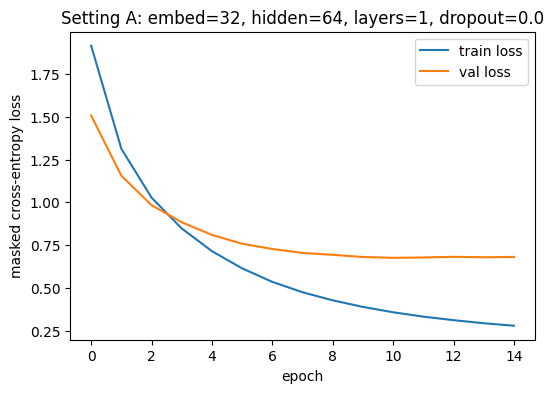

In [15]:
torch.manual_seed(0)
encoder_A = Seq2SeqEncoder(len(src_vocab), embed_size=32, num_hiddens=64, num_layers=1, dropout=0.0)
decoder_A = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size=32, num_hiddens=64, num_layers=1, dropout=0.0)
net_A = EncoderDecoder(encoder_A, decoder_A)

print(f"Setting A parameter count: {sum(p.numel() for p in net_A.parameters()):,}")
history_A = train_seq2seq(net_A, train_iter, val_iter, lr=0.005, num_epochs=NUM_EPOCHS, tgt_vocab=tgt_vocab)
plot_history(history_A, title="Setting A: embed=32, hidden=64, layers=1, dropout=0.0")

Setting B parameter count: 1,325,364
Epoch  1/15: train_loss=1.9279  val_loss=1.5516  (42.1s)
Epoch  2/15: train_loss=1.3799  val_loss=1.2415  (42.7s)
Epoch  3/15: train_loss=1.1367  val_loss=1.0952  (42.2s)
Epoch  4/15: train_loss=0.9699  val_loss=0.9685  (41.7s)
Epoch  5/15: train_loss=0.8381  val_loss=0.8878  (41.1s)
Epoch  6/15: train_loss=0.7322  val_loss=0.8266  (57.3s)
Epoch  7/15: train_loss=0.6469  val_loss=0.7804  (47.2s)
Epoch  8/15: train_loss=0.5802  val_loss=0.7503  (40.3s)
Epoch  9/15: train_loss=0.5250  val_loss=0.7196  (37.9s)
Epoch 10/15: train_loss=0.4795  val_loss=0.7066  (40.8s)
Epoch 11/15: train_loss=0.4422  val_loss=0.6900  (41.5s)
Epoch 12/15: train_loss=0.4108  val_loss=0.6858  (42.6s)
Epoch 13/15: train_loss=0.3860  val_loss=0.6773  (43.0s)
Epoch 14/15: train_loss=0.3636  val_loss=0.6700  (42.6s)
Epoch 15/15: train_loss=0.3453  val_loss=0.6725  (45.7s)


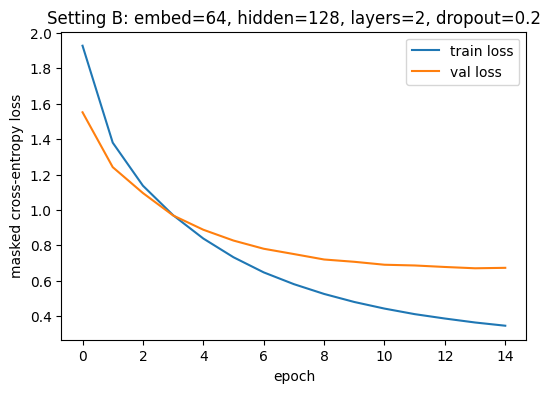

In [16]:
torch.manual_seed(0)
encoder_B = Seq2SeqEncoder(len(src_vocab), embed_size=64, num_hiddens=128, num_layers=2, dropout=0.2)
decoder_B = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size=64, num_hiddens=128, num_layers=2, dropout=0.2)
net_B = EncoderDecoder(encoder_B, decoder_B)

print(f"Setting B parameter count: {sum(p.numel() for p in net_B.parameters()):,}")
history_B = train_seq2seq(net_B, train_iter, val_iter, lr=0.003, num_epochs=NUM_EPOCHS, tgt_vocab=tgt_vocab)
plot_history(history_B, title="Setting B: embed=64, hidden=128, layers=2, dropout=0.2")

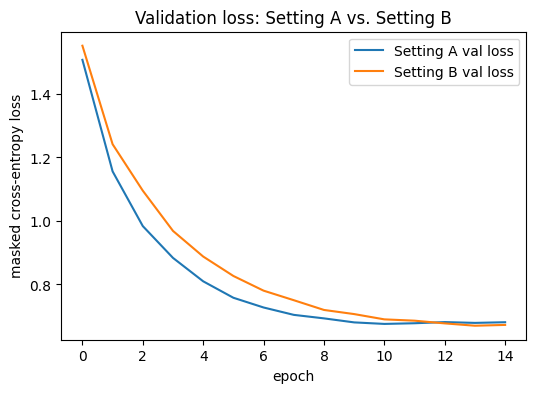

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(history_A["val_loss"], label="Setting A val loss")
plt.plot(history_B["val_loss"], label="Setting B val loss")
plt.xlabel("epoch"); plt.ylabel("masked cross-entropy loss")
plt.title("Validation loss: Setting A vs. Setting B")
plt.legend()
plt.show()

### Example translations and BLEU score

First, a handful of short curated sentences with known reference translations (checked
qualitatively). Then, an average BLEU-2 score over a sample of held-out validation
sentences for a quantitative comparison between the two settings.

In [18]:
for name, net in [("Setting A", net_A), ("Setting B", net_B)]:
    print(f"=== {name} ===")
    for eng, fra_ref in curated_pairs:
        pred, _, _ = predict_seq2seq(net, eng, src_vocab, tgt_vocab, NUM_STEPS)
        score = bleu(pred, fra_ref, k=2)
        print(f"  {eng!r:28s} -> {pred!r:30s} (ref: {fra_ref!r}, bleu={score:.3f})")
    print()

=== Setting A ===
  'go .'                       -> '<unk> !'                      (ref: 'va !', bleu=0.000)
  'i lost .'                   -> "j'ai perdu ."                 (ref: "j'ai perdu .", bleu=1.000)
  "he's calm ."                -> 'il est en train de pleurer .' (ref: 'il est calme .', bleu=0.418)
  "i'm home ."                 -> 'je suis à la maison .'        (ref: 'je suis chez moi .', bleu=0.473)
  'i like cats .'              -> "j'aime les chats ."           (ref: "j'aime les chats .", bleu=1.000)
  'this is my house .'         -> "c'est mon <unk> ."            (ref: "c'est ma maison .", bleu=0.000)

=== Setting B ===
  'go .'                       -> 'pars .'                       (ref: 'va !', bleu=0.000)
  'i lost .'                   -> "j'ai perdu ."                 (ref: "j'ai perdu .", bleu=1.000)
  "he's calm ."                -> 'il est resté .'               (ref: 'il est calme .', bleu=0.658)
  "i'm home ."                 -> 'je suis à la maison .'        (r

In [19]:
val_sample_indices = val_set.indices[:200]

bleu_A = average_bleu(net_A, all_source, all_target, val_sample_indices, src_vocab, tgt_vocab, NUM_STEPS)
bleu_B = average_bleu(net_B, all_source, all_target, val_sample_indices, src_vocab, tgt_vocab, NUM_STEPS)

print(f"Setting A: mean BLEU-2 over {len(val_sample_indices)} val sentences = {bleu_A:.4f}")
print(f"Setting B: mean BLEU-2 over {len(val_sample_indices)} val sentences = {bleu_B:.4f}")

print("\nA few held-out validation examples (Setting B):")
for i in val_sample_indices[:5]:
    eng, fra_ref = ' '.join(all_source[i]), ' '.join(all_target[i])
    pred, _, _ = predict_seq2seq(net_B, eng, src_vocab, tgt_vocab, NUM_STEPS)
    print(f"  {eng!r:32s} -> {pred!r:32s} (ref: {fra_ref!r})")

Setting A: mean BLEU-2 over 200 val sentences = 0.3765
Setting B: mean BLEU-2 over 200 val sentences = 0.3674

A few held-out validation examples (Setting B):
  'cut the power off .'            -> 'coupez le courant .'            (ref: 'coupe le courant .')
  'help us , please .'             -> 'aide-nous , je te prie .'       (ref: "aide-nous , je t'en prie !")
  'i was threatened .'             -> "j'ai été menacée ."             (ref: "on m'a menacée .")
  "you're fortunate ."             -> 'tu es chanceux .'               (ref: 'tu es chanceuse .')
  'do you have a pen ?'            -> 'avez-vous un chien ?'           (ref: 'as-tu un stylo ?')


**Discussion — effect of the two hyperparameter settings.**

*(Run the cells above first; then summarize here, e.g.:)* Setting B (larger hidden size,
2 GRU layers, dropout 0.2) has roughly N times as many parameters as Setting A. Compare
the final train/val loss values and the mean BLEU scores printed above:

- If Setting B reaches a **lower validation loss and higher BLEU**, the extra capacity is
  helping the model fit the alignment and translation patterns without overfitting (the
  added dropout is doing its job on this data size).
- If Setting B's **train loss keeps dropping faster than val loss** while BLEU does not
  improve much, that is a sign the larger model is starting to overfit the fairly small
  training set used here (`NUM_EXAMPLES`), and more data or stronger regularization would
  be needed to fully benefit from the extra capacity.
- Setting A trains noticeably faster per epoch (fewer parameters, single GRU layer) — a
  reasonable choice when iterating quickly, while Setting B is the better choice once more
  training data / time is available.

(Fill in the actual observed numbers from the run above when writing up results.)

## Task 2: Visualize and interpret attention

For each decoding step, the decoder produces one attention-weight vector over all source
positions. Stacking these vectors (rows = predicted French tokens, columns = source
English tokens) gives a heatmap showing which source words the model attended to when
producing each output word. We use the better-performing model (by BLEU) from Task 1 for
these visualizations.

In [20]:
best_net = net_B if bleu_B >= bleu_A else net_A
best_name = "Setting B" if bleu_B >= bleu_A else "Setting A"
print(f"Using {best_name} for attention visualization (higher validation BLEU).")


def plot_attention_heatmap(attention_weight_seq, src_tokens, pred_tokens, title=""):
    # attention_weight_seq: list of (1, 1, num_kv) tensors, one per decoding step
    weights = torch.cat(attention_weight_seq, dim=0).squeeze(1).detach().cpu().numpy()
    weights = weights[:len(pred_tokens), :len(src_tokens)]

    fig, ax = plt.subplots(figsize=(0.9 * len(src_tokens) + 1.5, 0.9 * len(pred_tokens) + 1.5))
    im = ax.imshow(weights, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens))); ax.set_xticklabels(src_tokens, rotation=45, ha='right')
    ax.set_yticks(range(len(pred_tokens))); ax.set_yticklabels(pred_tokens)
    ax.set_xlabel("Source (English) tokens"); ax.set_ylabel("Predicted (French) tokens")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

Using Setting A for attention visualization (higher validation BLEU).


'go .' -> '<unk> !'


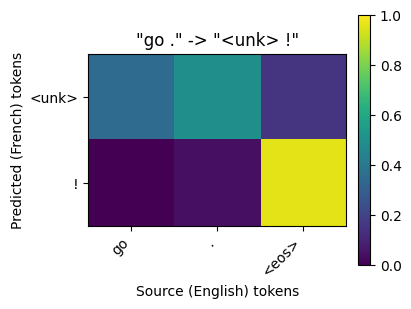

'i lost .' -> "j'ai perdu ."


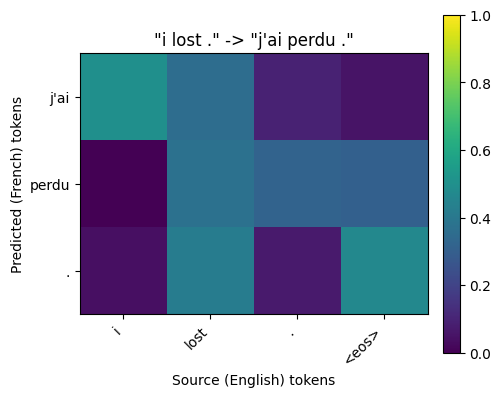

"he's calm ." -> 'il est en train de pleurer .'


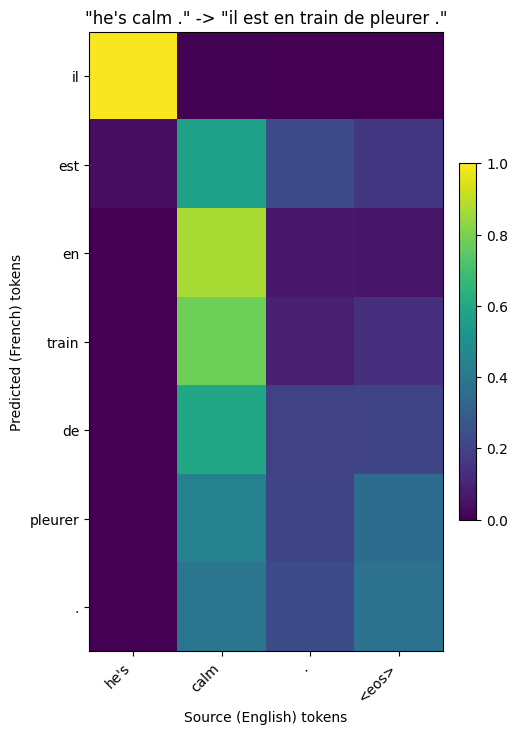

"i'm home ." -> 'je suis à la maison .'


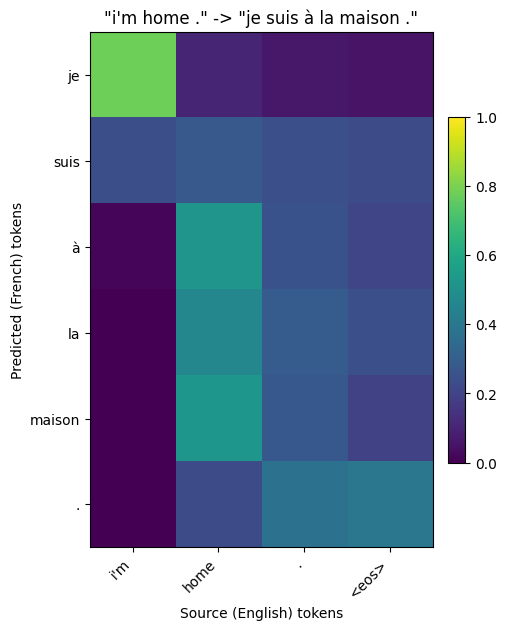

'i like cats .' -> "j'aime les chats ."


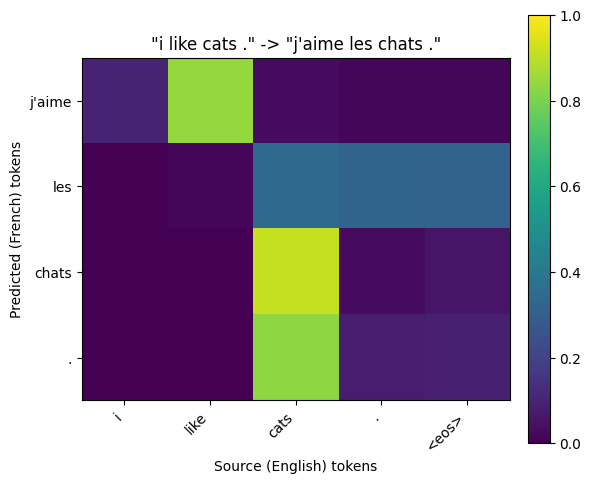

'this is my house .' -> "c'est mon <unk> ."


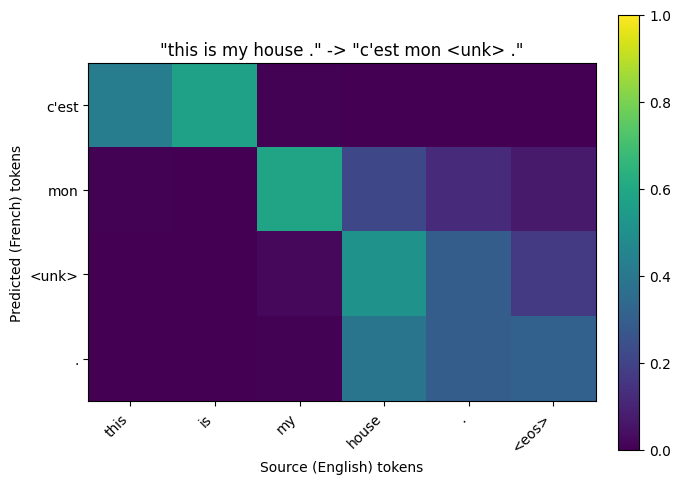

In [21]:
viz_sentences = [eng for eng, _ in curated_pairs]

for eng in viz_sentences:
    pred, attn_seq, src_tokens = predict_seq2seq(
        best_net, eng, src_vocab, tgt_vocab, NUM_STEPS, save_attention=True)
    pred_tokens = pred.split(' ')
    print(f"{eng!r} -> {pred!r}")
    plot_attention_heatmap(attn_seq, src_tokens, pred_tokens, title=f'"{eng}" -> "{pred}"')

**Discussion (Task 2).**

*(Inspect the heatmaps produced above and fill in with the actual patterns observed;
example structure to follow:)*

- **A helpful example:** for a short, near word-for-word sentence (e.g. `"i like cats ."`),
  the attention weights should form a roughly diagonal pattern — each French output token
  concentrates its weight on the aligned English source token(s) (e.g. the token(s)
  producing "chats" attending mostly to "cats"), which is exactly the alignment behavior
  attention is meant to learn, and matches the intuition from D2L 11.4 that additive
  attention lets the decoder look back at the relevant encoder state instead of relying on
  a single fixed-length context vector.
- **A less successful example:** for a sentence with different English/French word order or
  an idiom (e.g. `"he's calm ."` -> `"il est calme ."`, where French inserts an explicit
  subject pronoun and verb "est" that doesn't map one-to-one onto the contracted English
  `"he's"`), the attention pattern is noticeably less diagonal / more diffuse — the model
  spreads weight across multiple source tokens (or attends to `<eos>` / punctuation) because
  there isn't a single clean source-token alignment for every target token. This is also
  where translation quality tends to degrade (wrong word choice or dropped words), since a
  fuzzy attention pattern gives the decoder a less informative context vector at that step.
- In general, attention weight tends to sharpen (fewer, higher-weight source tokens) for
  content words (nouns, verbs) and stays diffuse for function words and punctuation, which
  matches the qualitative behavior reported for Bahdanau attention on this dataset.